In [2]:
### forest analysis 2 --
### need 'd2' for python environment
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from osgeo import gdal
from shapely.geometry import MultiPolygon
from shapely.ops import unary_union
import csv
import sys

In [1]:
### load in min/max scaling values 
combined_min = np.genfromtxt("../data/ml_sets/pyramid_v10/norm_layer_mins_combined.csv", delimiter=',')
combined_max = np.genfromtxt( "../data/ml_sets/pyramid_v10/norm_layer_maxs_combined.csv", delimiter=',')

NameError: name 'np' is not defined

In [2]:
### load... EVT metadata
evt_metadata_cats = {}
with open("../data/raw/raw_raster/src/LF2022_EVT_230_CONUS/CSV_Data/LF22_EVT_230.csv") as csv_file:
    csv_read=csv.reader(csv_file, delimiter=',')
    firstflag = False
    for row in csv_read:
        #print(row)
        if firstflag:
            evt_metadata_cats[int(row[0])] = [row[1], float(row[13])/255, float(row[14])/255, float(row[15])/255]
        else:
            firstflag = True

### test... print metadata 
for k in evt_metadata_cats:
    print(k, evt_metadata_cats[k])

-9999 ['Fill-NoData', 1.0, 1.0, 1.0]
4401 ['Alaska Arctic Coastal Sedge-Dwarf-Shrubland', 1.0, 0.803921568627451, 0.4392156862745098]
4402 ['Alaska Arctic Floodplain Forest', 0.07058823529411765, 0.2980392156862745, 0.5294117647058824]
4403 ['Alaska Arctic Large River Floodplain Forest', 0.07058823529411765, 0.2980392156862745, 0.5294117647058824]
4404 ['Alaska Arctic Mesic Alder Shrubland', 0.5725490196078431, 0.9294117647058824, 0.8784313725490196]
4405 ['Alaska Arctic Permafrost Plateau Dwarf-Shrub Lichen Tundra', 1.0, 0.1450980392156863, 0.050980392156862744]
4406 ['Alaska Arctic Tidal Flat', 1.0, 0.6, 0.0392156862745098]
4407 ['Alaska Sub-boreal and Maritime Alpine Mesic Herbaceous Meadow', 1.0, 0.8274509803921568, 0.4666666666666667]
4408 ['Alaska Sub-boreal Mesic Subalpine Alder Shrubland', 0.5725490196078431, 0.9294117647058824, 0.8784313725490196]
4409 ['Alaska Sub-boreal Mountain Hemlock-White Spruce Forest', 0.7137254901960784, 0.9803921568627451, 0.8901960784313725]
4410 ['

In [3]:
### need to load the output file of geoplotting.py
comps = np.load('../visualize/geographic/comparicomputations.npy')
print("loaded")

### need to split, for each plot, into evt segments
### for each unique value found in EVT.... separate out
uniqueset = {}
for i in range(len(comps)):
    if comps[i][0] not in uniqueset:
        uniqueset[comps[i][0]] = [[], evt_metadata_cats[comps[i][0]]]
    else:
        uniqueset[comps[i][0]][0].append(comps[i])

print(len(uniqueset.keys()))
evt_keys = list(uniqueset.keys())
for colork in evt_keys:
    uniqueset[colork][0] = np.array(uniqueset[colork][0])
    print(uniqueset[colork][0].shape)

loaded
103
(12850921, 7)
(12379648, 7)
(6597775, 7)
(20400174, 7)
(2960491, 7)
(960978, 7)
(6831415, 7)
(71133, 7)
(12874136, 7)
(7841319, 7)
(572275, 7)
(146221, 7)
(2835155, 7)
(2692748, 7)
(825608, 7)
(1151052, 7)
(701509, 7)
(583053, 7)
(1354771, 7)
(597832, 7)
(1583053, 7)
(4306, 7)
(2990855, 7)
(700623, 7)
(490986, 7)
(423236, 7)
(280741, 7)
(434820, 7)
(633715, 7)
(254698, 7)
(200502, 7)
(96150, 7)
(27171, 7)
(368747, 7)
(395083, 7)
(28980, 7)
(199452, 7)
(71234, 7)
(155643, 7)
(170487, 7)
(220291, 7)
(170972, 7)
(453537, 7)
(22469, 7)
(99955, 7)
(121451, 7)
(78329, 7)
(117021, 7)
(40498, 7)
(133251, 7)
(87982, 7)
(1936, 7)
(17438, 7)
(66565, 7)
(152605, 7)
(405446, 7)
(34073, 7)
(139795, 7)
(29100, 7)
(17624, 7)
(12099, 7)
(72582, 7)
(4415, 7)
(19897, 7)
(4948, 7)
(11962, 7)
(10790, 7)
(16933, 7)
(9932, 7)
(4908, 7)
(2803, 7)
(8272, 7)
(25110, 7)
(13468, 7)
(12915, 7)
(6238, 7)
(1311, 7)
(17290, 7)
(223, 7)
(2778, 7)
(5637, 7)
(77, 7)
(10769, 7)
(4156, 7)
(2532, 7)
(8204, 7)
(9

In [4]:
freq = []
names = []
print(len(comps))
### iterate over unique keys... compute frequencies of different land color types
for colork in evt_keys:
    #print(uniqueset[colork][1][0], len(uniqueset[colork][0])/ len(comps))
    freq.append(len(uniqueset[colork][0]))
    names.append(uniqueset[colork][1][0])

### for plotting here... compute pct of total
freq = np.array(freq)
argsrted = np.argsort(-freq)
sumpct = 0
for i in range(len(freq)):
    print(names[argsrted[i]], freq[argsrted[i]] / len(comps))
    sumpct += freq[argsrted[i]]
    if i == 7:
        print(sumpct / len(comps))
    if i == 12:
        print(sumpct / len(comps))

reduced_keys = []
reduced_names = []
reduced_pct = []
#reduced_set = {}
for i in range(8):
    reduced_names.append(names[argsrted[i]])
    reduced_keys.append(evt_keys[argsrted[i]])
    reduced_pct.append(float(freq[argsrted[i]] / len(comps)))
#reduced_pct = np.array(reduced_pct).astype(float)

107449035
Rocky Mountain Subalpine Dry-Mesic Spruce-Fir Forest and Woodland 0.18985907132623386
Colorado Plateau Pinyon-Juniper Woodland 0.11981620867977083
Rocky Mountain Aspen Forest and Woodland 0.11960015276079491
Southern Rocky Mountain Ponderosa Pine Woodland 0.11521413849831225
Rocky Mountain Lodgepole Pine Forest 0.07297710025967194
Southern Rocky Mountain Dry-Mesic Montane Mixed Conifer Forest and Woodland 0.06357818848722094
Rocky Mountain Gambel Oak-Mixed Montane Shrubland 0.06140376225807891
Southern Rocky Mountain Pinyon-Juniper Woodland 0.027835103405070134
0.7702837256751538
Inter-Mountain Basins Montane Sagebrush Steppe 0.027552513617269805
Southern Rocky Mountain Mesic Montane Mixed Conifer Forest and Woodland 0.0263860443232459
Southern Rocky Mountain Montane-Subalpine Grassland 0.025060699707540417
Inter-Mountain Basins Big Sagebrush Shrubland 0.014733059259210658
Rocky Mountain Subalpine-Montane Mesic Meadow 0.012608498531420036
0.8766245411138406
Rocky Mountain Low

In [5]:
for i in range(len(reduced_pct)):
    reduced_pct[i] *= 100

Text(0.5, 1.0, 'Existing Vegetation Type Frequency (Top 8)')

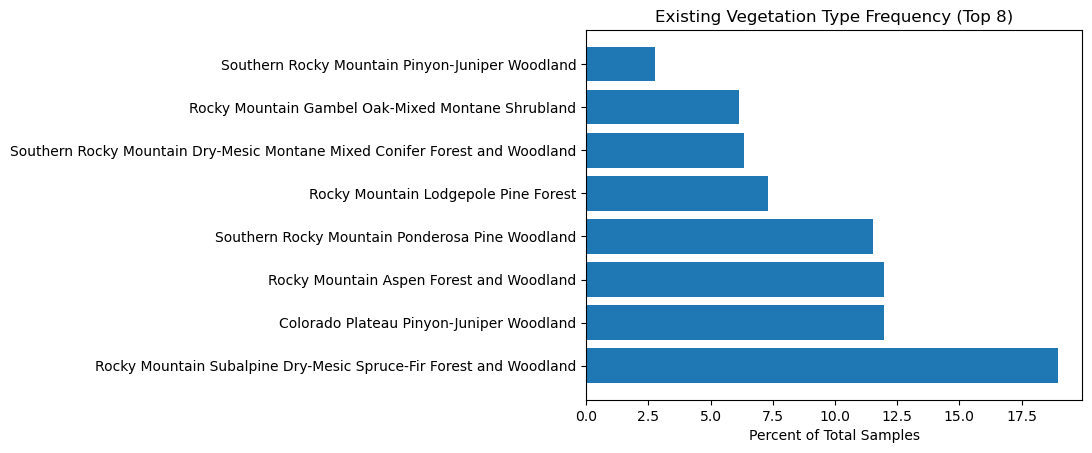

In [6]:
plt.barh(reduced_names, reduced_pct)
plt.xlabel("Percent of Total Samples")
plt.title("Existing Vegetation Type Frequency (Top 8)")

In [7]:
reorder9 = [7055.0, 7011.0, 7050.0, 7107.0, 7054.0, 7051.0, 7059.0, 7016.0]
print(reorder9)

[7055.0, 7011.0, 7050.0, 7107.0, 7054.0, 7051.0, 7059.0, 7016.0]


In [ ]:
### rescale evc

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_60204/100760175.py:4: SyntaxWarning: invalid escape sequence '\m'
  nice_y_names = ["Predicted Water Use Efficiency \n (g C kg$\mathregular{^{-1}}$ H$\mathregular{_2}$O)",
/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_60204/100760175.py:5: SyntaxWarning: invalid escape sequence '\m'
  "Predicted Evaporative Stress Index", "Predicted Above Ground Biomass \n (Mg ha$\mathregular{^{-1}}$)"]
/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_60204/100760175.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colorsm = plt.cm.get_cmap('hsv',

KeyboardInterrupt: 

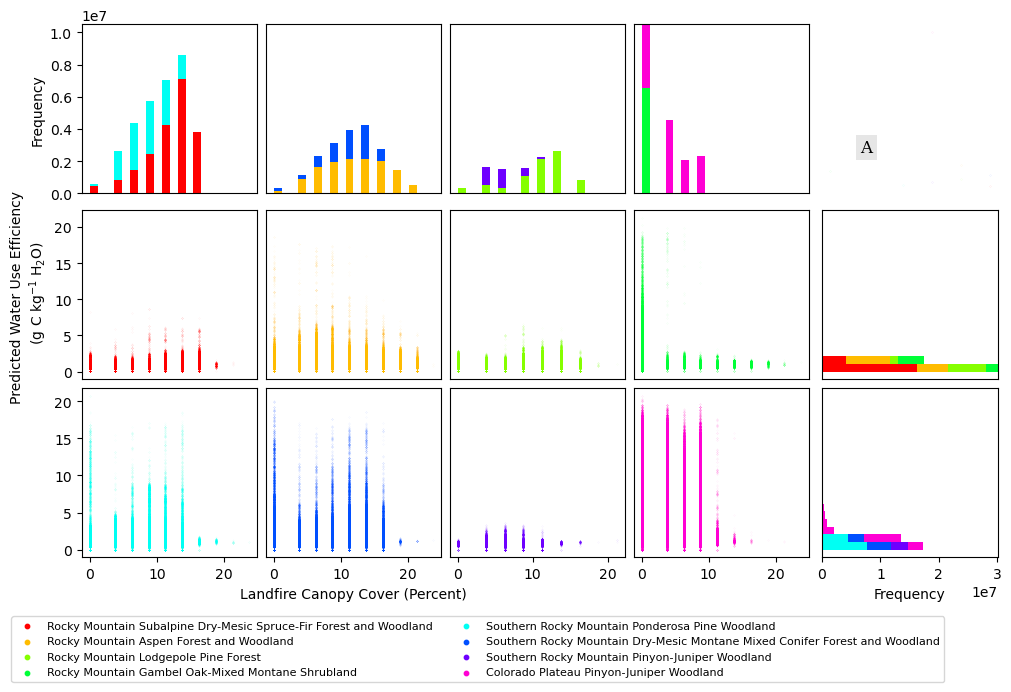

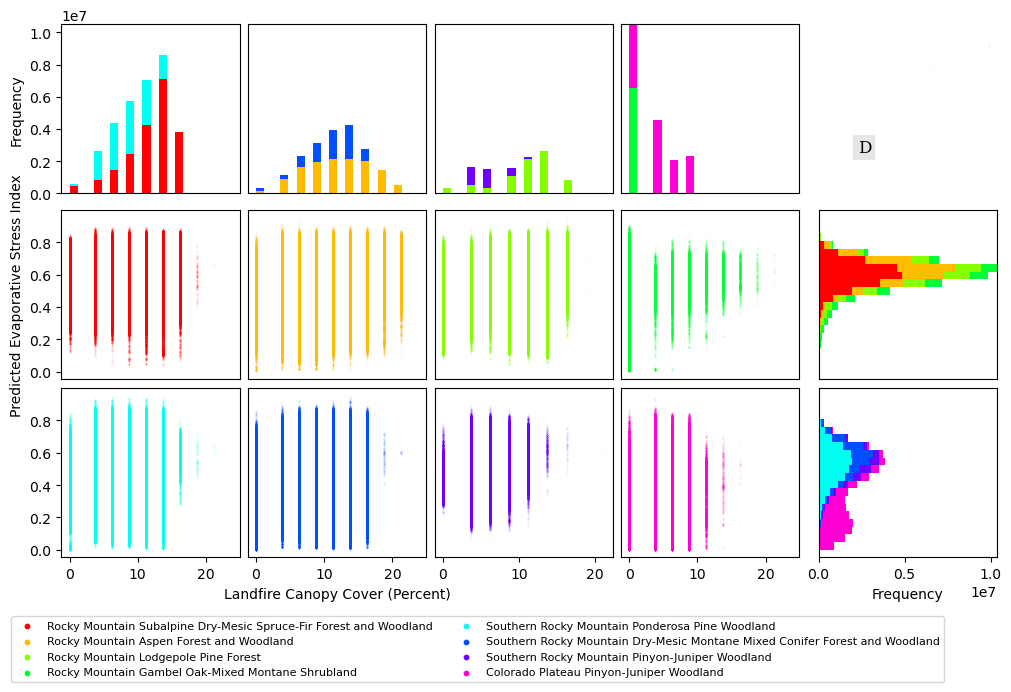

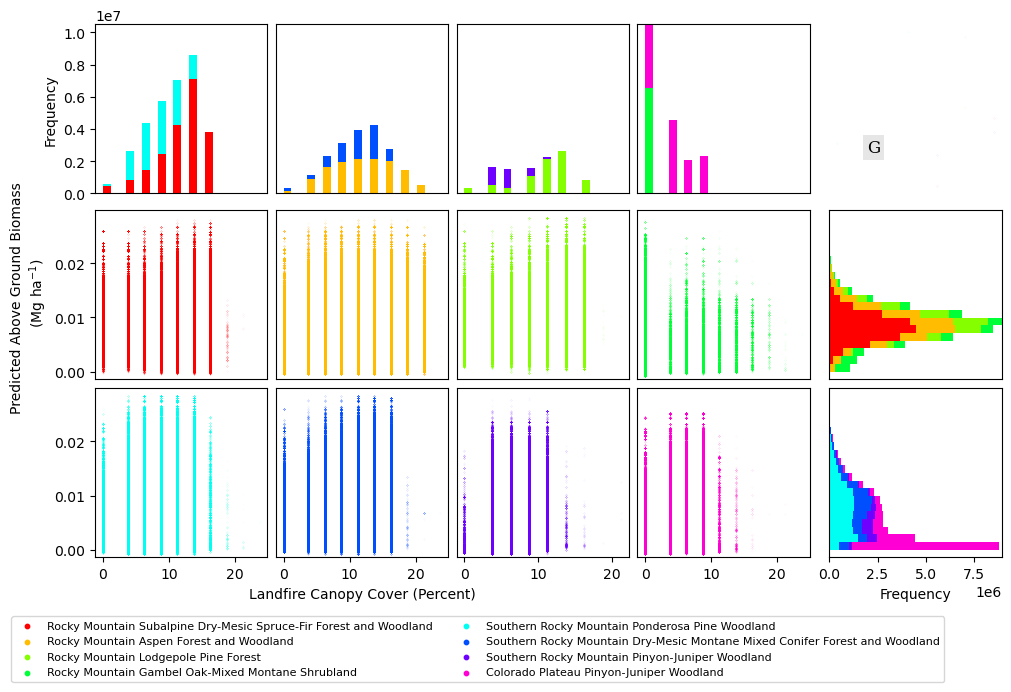

In [ ]:
xkeys = ["lf_cc", "lf_evc", "standage"]
ykeys = ["yhat_wue", "yhat_esi", "yhat_agb"]
nice_x_names = ["Landfire Canopy Cover (Percent)", "Landfire Existing Vegetation Cover (Percent)", "Forest Stand Age (Years)"]
nice_y_names = ["Predicted Water Use Efficiency \n (g C kg$\mathregular{^{-1}}$ H$\mathregular{_2}$O)", 
                "Predicted Evaporative Stress Index", "Predicted Above Ground Biomass \n (Mg ha$\mathregular{^{-1}}$)"]
nice_x_title = ["Landfire Canopy Cover ", "Landfire Existing Vegetation Cover", "Forest Stand Age"]
#letters = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]
letters = ["A", "D", "G", "B", "E", "H", "C", "F", "I"]
letterctr = 0
nbins_each = 20


## (g C kg$\mathregular{^-1}$ H $\mathregular{_2}$ O)
## ($g C kg^{-1} H_2O$)

ngrid = [2, 4]
colorsm = plt.cm.get_cmap('hsv', 9)

for xkey in range(len(xkeys)):
    for ykey in range(len(ykeys)):
        fig, axs = plt.subplots(ngrid[0]+1, ngrid[1]+1, layout='constrained', figsize=(10, 6), gridspec_kw = {'wspace': 0, 'hspace':0})#, sharex=True, sharey=True)

        ax_histxs = []
        ax_histys = []
        
        gridhisty = [[] for ii in range(ngrid[0])]
        gridhistx = [[] for ii in range(ngrid[1])]
        gridcoloy = [[] for ii in range(ngrid[0])]
        gridcolox = [[] for ii in range(ngrid[1])]
        x_max = [[] for ii in range(ngrid[1])]
        y_max = [[] for ii in range(ngrid[0])]
        gridctr = 0
        ### iterate over rows?
        for i in range(ngrid[0]):
            ### iterate over cols
            for j in range(ngrid[1]):
                if True:
                    axs[i+1, j].scatter(uniqueset[reorder9[gridctr]][0][:,xkey+4], uniqueset[reorder9[gridctr]][0][:,ykey+1], s=0.01, 
                                alpha=0.2, #label=uniqueset[reorder9[gridctr]][1][0], 
                                color=colorsm(gridctr))
                    ### for legend
                    axs[0, ngrid[1]].scatter(uniqueset[reorder9[gridctr]][0][:1,xkey+4], uniqueset[reorder9[gridctr]][0][:1,ykey+1], s=0.001, 
                                label=uniqueset[reorder9[gridctr]][1][0], 
                                color=colorsm(gridctr))
                    
                gridhistx[j].append(uniqueset[reorder9[gridctr]][0][:,xkey+4])
                gridhisty[i].append(uniqueset[reorder9[gridctr]][0][:,ykey+1])

                gridcolox[j].append(colorsm(gridctr))
                gridcoloy[i].append(colorsm(gridctr))

                ### this is one for each on x axis (4)... add one for each y in this x position
                x_max[j].append(np.nanmax(uniqueset[reorder9[gridctr]][0][:,xkey+4]))
                ### this is one for each on y axis (2)
                y_max[i].append(np.nanmax(uniqueset[reorder9[gridctr]][0][:,ykey+1]))

                if j != 0:
                    axs[i+1,j].set_yticks([])
                if i+1 != ngrid[0]:
                    axs[i+1,j].set_xticks([])
                #axs[i+1, j].legend(loc='lower left', bbox_to_anchor=(1.02 + (i/10), 1.02), markerscale=10)
                ##loc='lower left', bbox_to_anchor=(1.02, 1.02), prop={'size': 5},markerscale=10
                gridctr += 1
        #print(x_max)
        #print(y_max)

        #axs[0, ngrid[1]].text(0, 0, letters[letterctr], fontsize=40,
        #verticalalignment='bottom', horizontalalignment='left')#, bbox=props)
        
        for i in range(ngrid[0]):
            supermax = max(y_max[i])
            superdiff = supermax * 0.05
            for j in range(ngrid[1]):
                axs[i+1, j].set_ybound(-superdiff, supermax + superdiff)
        for j in range(ngrid[1]):
            supermax = max(x_max[j])
            superdiff = supermax * 0.05
            for i in range(ngrid[0]):
                axs[i+1, j].set_xbound(-superdiff, supermax+superdiff)
        #x_min = []
        #y_min = []
        x_max = []
        y_max = []
        for ng in range(ngrid[1]):
            (ngnx, ngbinsx, ngpatchesx) = axs[0, ng].hist(gridhistx[ng], nbins_each, histtype='bar', stacked=True, log=False, color=gridcolox[ng]) #density=True
            x_max.append(np.max(ngnx))
            axs[0, ng].set_xticks([])
            if ng != 0:
                axs[0, ng].set_yticks([])
        for ng in range(ngrid[0]):
            (ngny, ngbinsy, ngpatchesy) = axs[ng+1, ngrid[1]].hist(gridhisty[ng], nbins_each, histtype='bar', stacked=True, log=False, orientation='horizontal', color=gridcoloy[ng])
            y_max.append(np.max(ngny))
            axs[ng+1, ngrid[1]].set_yticks([])
            if ng+1 != ngrid[0]:
                axs[ng+1, ngrid[1]].set_xticks([])
        true_y_max = max(y_max)
        true_x_max = max(x_max)
        #print(max(x_max), max(y_max))
        for ng in range(ngrid[0]):
            axs[ng+1, ngrid[1]].set_xbound(0, true_y_max)
        for ng in range(ngrid[1]):
            axs[0, ng].set_ybound(0, true_x_max)
        
        axs[ngrid[0], 1].set_xlabel(nice_x_names[xkey])
        axs[1, 0].set_ylabel(nice_y_names[ykey])
        axs[0, 0].set_ylabel("Frequency")
        axs[ngrid[0], ngrid[1]].set_xlabel("Frequency")

        fig.legend(loc='upper left', bbox_to_anchor=(0, -0.01), ncol=2, markerscale=100, prop={'size': 8})
        axs[0, ngrid[1]].annotate(letters[letterctr], xy=(0.2, 0.2), xycoords='axes fraction', textcoords='offset fontsize',
        fontsize='large', verticalalignment='bottom', horizontalalignment='left', fontfamily='serif',
        bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))
        #axs[0, ngrid[1]].legend(loc='lower right', bbox_to_anchor=(0.05, 1.05), fancybox=True, shadow=True, 
        #                        ncol=2, markerscale=10, prop={'size': 5})
        #axs[0, ngrid[1]].legend(loc='lower left', bbox_to_anchor=(0, 0), markerscale=20, prop={'size': 5})
        axs[0, ngrid[1]].axis('off')
        #axs[0, 3].set_title("Late-Combination CNN " + nice_y_names[ykey] + " Versus " + nice_x_title[xkey] + "\nOver Landfire Vegetation Types")

        plt.savefig("../visualize/covars/8box_" + xkeys[xkey] + "_" + ykeys[ykey] + ".png", bbox_inches = 'tight')
        letterctr += 1
        #break
    #break
